In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
df=pd.read_csv("/content/sample_data/california_housing_test.csv")

In [5]:
import pandas as pd


In [8]:
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  


In [11]:
df.isnull()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2995,False,False,False,False,False,False,False,False,False
2996,False,False,False,False,False,False,False,False,False
2997,False,False,False,False,False,False,False,False,False
2998,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [20]:
print(df.columns)



Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [23]:
from sklearn.datasets import fetch_california_housing


In [25]:
data = fetch_california_housing()
df=pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['Region']=np.random.choice(['North', 'South', 'East', 'West'], size=len(df))
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target Region  
0    -122.23   4.526   West  
1    -122.22   3.585  South  
2    -122.24   3.521  North  
3    -122.25   3.413   East  
4    -122.25   3.422  North  


#label encoding

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [28]:
le=LabelEncoder()
df['Region']=le.fit_transform(df['Region'])
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  Region  
0    -122.23   4.526       3  
1    -122.22   3.585       2  
2    -122.24   3.521       1  
3    -122.25   3.413       0  
4    -122.25   3.422       1  


#one-hot encoding

In [29]:
df_encoded=pd.get_dummies(df, columns=['Region'])
print(df_encoded.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  Region_0  Region_1  Region_2  Region_3  
0    -122.23   4.526     False     False     False      True  
1    -122.22   3.585     False     False      True     False  
2    -122.24   3.521     False      True     False     False  
3    -122.25   3.413      True     False     False     False  
4    -122.25   3.422     False      True     False     False  


standardize the numerical features

In [32]:
scaler=StandardScaler()

numerical_columns=df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_columns]=scaler.fit_transform(df[numerical_columns])
print(df.head())

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.344766  0.982143  0.628559  -0.153758   -0.974429 -0.049597  1.052548   
1  2.332238 -0.607019  0.327041  -0.263336    0.861439 -0.092512  1.043185   
2  1.782699  1.856182  1.155620  -0.049016   -0.820777 -0.025843  1.038503   
3  0.932968  1.856182  0.156966  -0.049833   -0.766028 -0.050329  1.038503   
4 -0.012881  1.856182  0.344711  -0.032906   -0.759847 -0.085616  1.038503   

   Longitude    target    Region  
0  -1.327835  2.129631  1.346944  
1  -1.322844  1.314156  0.451642  
2  -1.332827  1.258693 -0.443660  
3  -1.337818  1.165100 -1.338963  
4  -1.337818  1.172900 -0.443660  


normalize the numerical function

In [33]:
min_max_scaler=MinMaxScaler()
df[numerical_columns]=min_max_scaler.fit_transform(df[numerical_columns])
print(df.head())

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  0.539668  0.784314  0.043512   0.020469    0.008941  0.001499  0.567481   
1  0.538027  0.392157  0.038224   0.018929    0.067210  0.001141  0.565356   
2  0.466028  1.000000  0.052756   0.021940    0.013818  0.001698  0.564293   
3  0.354699  1.000000  0.035241   0.021929    0.015555  0.001493  0.564293   
4  0.230776  1.000000  0.038534   0.022166    0.015752  0.001198  0.564293   

   Longitude    target    Region  
0   0.211155  0.902266  1.000000  
1   0.212151  0.708247  0.666667  
2   0.210159  0.695051  0.333333  
3   0.209163  0.672783  0.000000  
4   0.209163  0.674638  0.333333  


visualize the data using boxplot


In [42]:
import seaborn as sns


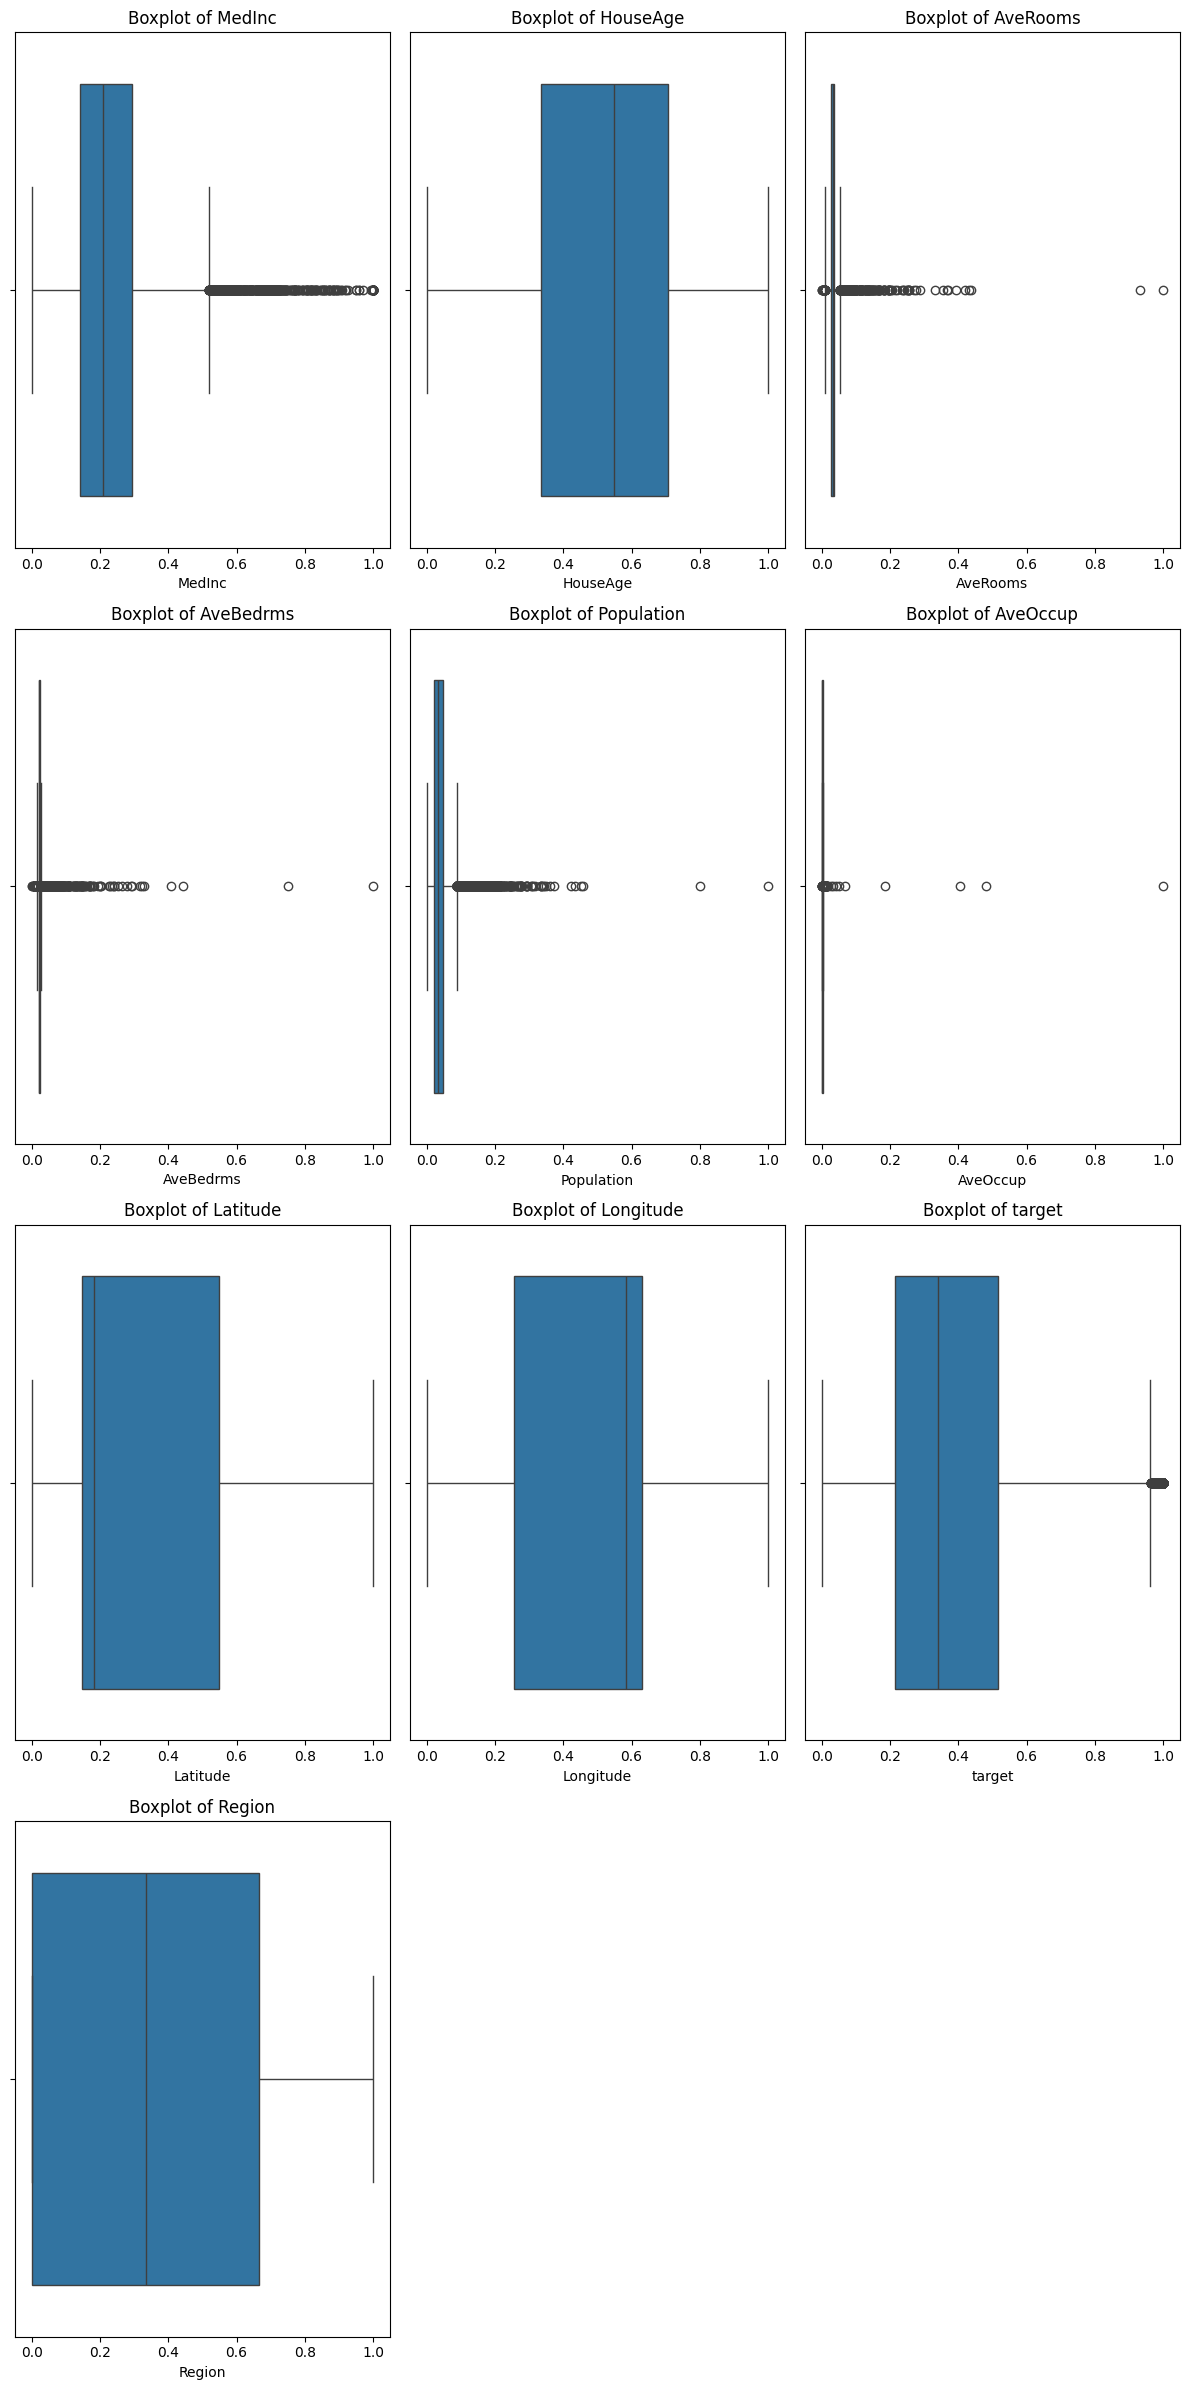

In [43]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

num_columns = len(numerical_columns)
rows = (num_columns // 3) + (num_columns % 3 > 0)

plt.figure(figsize=(12, 6 * rows))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

remove outliers using the IQR method

In [49]:
def remove_outliers(df,columns):
  for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

  return df


  df_cleaned = remove_outliers(df, numerical_columns)
  print("\nOriginal data shape:", df.shape)
  print("Cleaned data shape:", df_cleaned.shape)

visualize the data after removing thw outliers

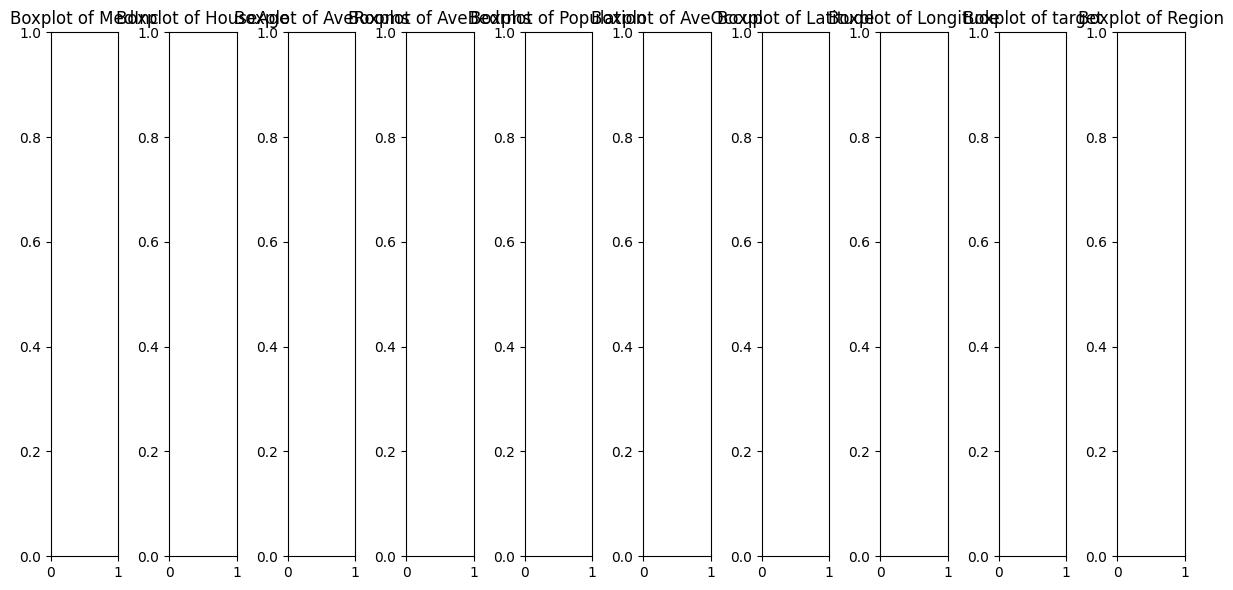

In [52]:
plt.figure(figsize=(12, 6))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i)

    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()